In [1]:
# =========================
# Block 1: Install + Imports
# =========================
!pip -q install pytesseract opencv-python-headless rapidfuzz scikit-learn

import os, glob, json, random, re, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import cv2
import pytesseract
from PIL import Image

from rapidfuzz import process, fuzz
from sklearn.metrics import confusion_matrix, classification_report, f1_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Ready.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 3.7 MB/s eta 0:00:00
Ready.


In [2]:
# ==========================================
# Block 2: Auto-detect Dataset A and B roots
# ==========================================

def find_dataset_A_processed_root():
    base = "/kaggle/input"
    for root, dirs, files in os.walk(base):
        if "processed" in dirs:
            cand = os.path.join(root, "processed")
            if os.path.exists(os.path.join(cand, "train_labels.csv")) and os.path.exists(os.path.join(cand, "mapping.json")):
                return cand
    raise FileNotFoundError("Dataset A not found. Expected processed/train_labels.csv + mapping.json under /kaggle/input.")

def find_dataset_B_images_root(min_images=20):
    # Pick folder with the most jpg/png/jpeg images (excluding Dataset A's processed folders).
    base = "/kaggle/input"
    best_root, best_count = None, 0
    for root, dirs, files in os.walk(base):
        # Skip dataset A processed folders if they appear
        if "processed" in root.lower():
            continue
        imgs = glob.glob(os.path.join(root, "*.jpg")) + glob.glob(os.path.join(root, "*.jpeg")) + glob.glob(os.path.join(root, "*.png"))
        if len(imgs) > best_count:
            best_count = len(imgs)
            best_root = root
    if best_root is None or best_count < min_images:
        raise FileNotFoundError("Dataset B not found. Expected a folder with many prescription images under /kaggle/input.")
    return best_root, best_count

A_PROC = find_dataset_A_processed_root()
B_ROOT, B_COUNT = find_dataset_B_images_root(min_images=20)

print("✅ Dataset A (processed):", A_PROC)
print("✅ Dataset B (prescription images root):", B_ROOT, "| images:", B_COUNT)

B_IMAGES = sorted(
    glob.glob(os.path.join(B_ROOT, "*.jpg")) +
    glob.glob(os.path.join(B_ROOT, "*.jpeg")) +
    glob.glob(os.path.join(B_ROOT, "*.png"))
)

print("Sample B images:", B_IMAGES[:3])


✅ Dataset A (processed): /kaggle/input/ocr-processed-handwritten-prescriptions/data/processed
✅ Dataset B (prescription images root): /kaggle/input/illegible-medical-prescription-images-dataset/data | images: 129
Sample B images: ['/kaggle/input/illegible-medical-prescription-images-dataset/data/1.jpg', '/kaggle/input/illegible-medical-prescription-images-dataset/data/10.jpg', '/kaggle/input/illegible-medical-prescription-images-dataset/data/100.jpg']


NUM_CLASSES: 78
Train/Val/Test: 3120 780 780


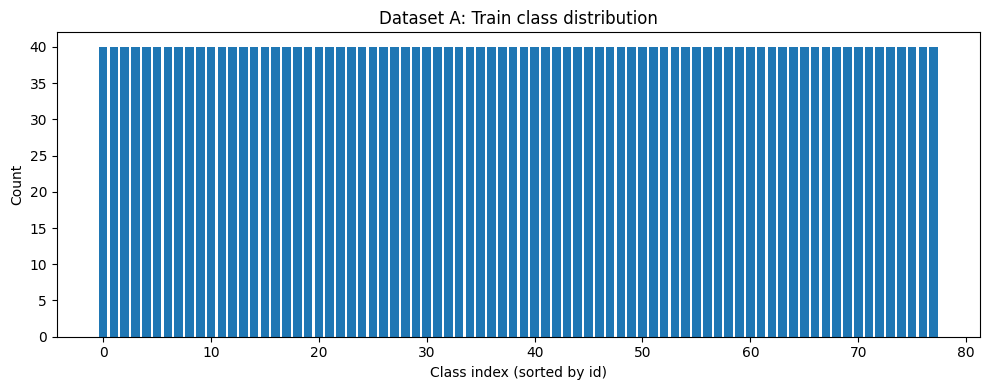

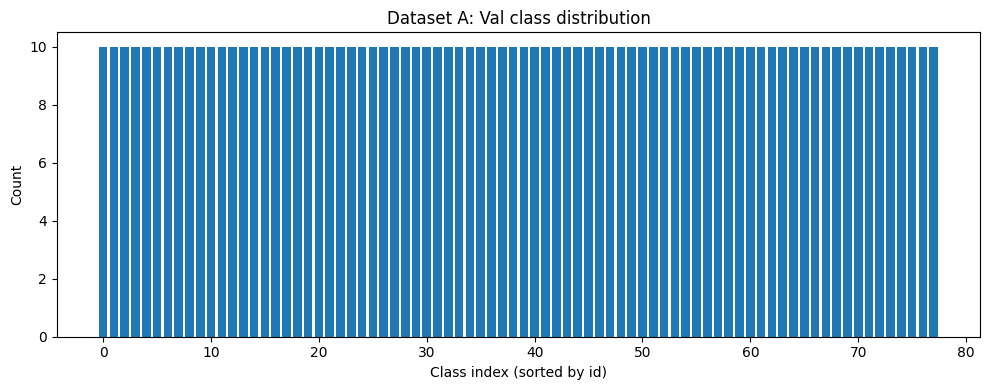

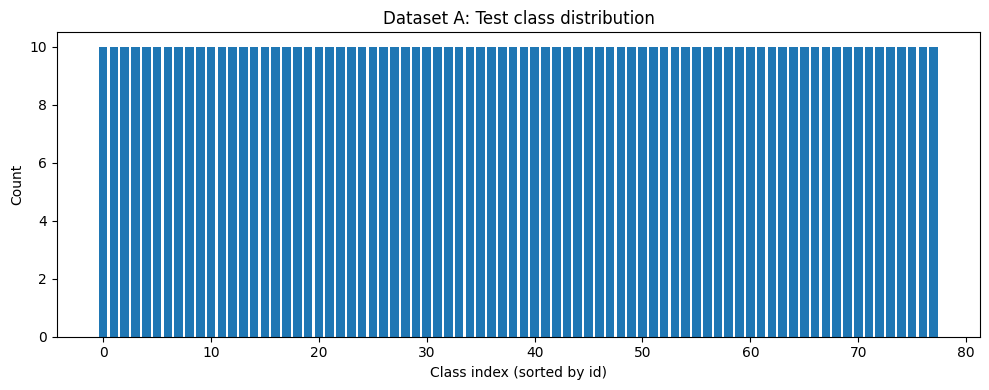

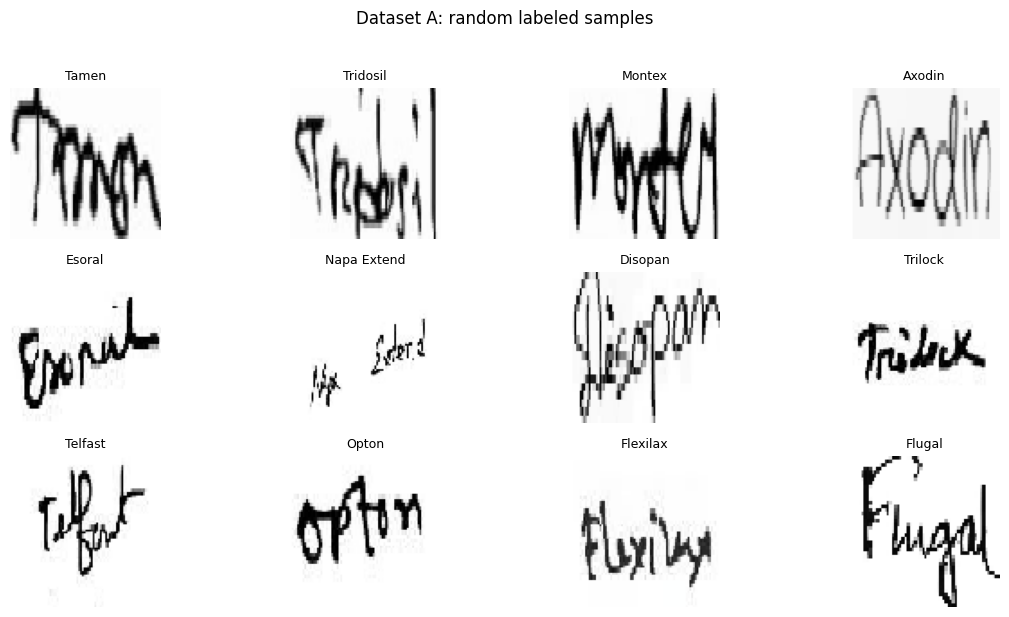

In [3]:
# ==========================================
# Block 3: Load Dataset A labels + mapping
# ==========================================

TRAIN_IMG_DIR = os.path.join(A_PROC, "train", "images")
VAL_IMG_DIR   = os.path.join(A_PROC, "val", "images")
TEST_IMG_DIR  = os.path.join(A_PROC, "test", "images")

train_df = pd.read_csv(os.path.join(A_PROC, "train_labels.csv"))
val_df   = pd.read_csv(os.path.join(A_PROC, "val_labels.csv"))
test_df  = pd.read_csv(os.path.join(A_PROC, "test_labels.csv"))

with open(os.path.join(A_PROC, "mapping.json"), "r") as f:
    mapping = json.load(f)  # medicine_name -> id
id_to_name = {v: k for k, v in mapping.items()}

NUM_CLASSES = len(mapping)
print("NUM_CLASSES:", NUM_CLASSES)
print("Train/Val/Test:", len(train_df), len(val_df), len(test_df))

def plot_class_dist(df, title):
    counts = df["MEDICINE_NAME"].value_counts().sort_index()
    plt.figure(figsize=(10,4))
    plt.bar(range(len(counts)), counts.values)
    plt.title(title)
    plt.xlabel("Class index (sorted by id)")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

plot_class_dist(train_df, "Dataset A: Train class distribution")
plot_class_dist(val_df, "Dataset A: Val class distribution")
plot_class_dist(test_df, "Dataset A: Test class distribution")

def show_samples_A(df, img_dir, n=12):
    samp = df.sample(min(n, len(df)), random_state=SEED).reset_index(drop=True)
    plt.figure(figsize=(12,6))
    for i in range(len(samp)):
        p = os.path.join(img_dir, samp.loc[i, "IMAGE"])
        y = int(samp.loc[i, "MEDICINE_NAME"])
        name = id_to_name.get(y, str(y))
        img = Image.open(p).convert("RGB")
        plt.subplot(3,4,i+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(name[:18], fontsize=9)
    plt.suptitle("Dataset A: random labeled samples", y=1.02)
    plt.tight_layout()
    plt.show()

show_samples_A(train_df, TRAIN_IMG_DIR, n=12)


In [4]:
# ==========================================
# Block 4: ROI detector + OCR (shared)
# ==========================================

def detect_rois_opencv(img_bgr, max_rois=12):
    """
    Fast ROI detection for text blocks.
    Returns list of (x,y,w,h).
    """
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    thr = cv2.adaptiveThreshold(
        gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV, 41, 11
    )
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 7))
    dil = cv2.dilate(thr, kernel, iterations=2)

    contours, _ = cv2.findContours(dil, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    h, w = gray.shape[:2]
    boxes = []
    for c in contours:
        x, y, bw, bh = cv2.boundingRect(c)
        area = bw * bh
        if area < 1500:
            continue
        if bw > 0.98*w and bh > 0.98*h:
            continue
        boxes.append((x, y, bw, bh))

    boxes = sorted(boxes, key=lambda b: b[2]*b[3], reverse=True)
    return boxes[:max_rois]

def ocr_with_rois(img_bgr, use_rois=True):
    if img_bgr is None:
        return ""

    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.bilateralFilter(gray, 7, 60, 60)

    texts = []
    if use_rois:
        boxes = detect_rois_opencv(img_bgr, max_rois=12)
        if len(boxes) == 0:
            boxes = [(0, 0, img_bgr.shape[1], img_bgr.shape[0])]
        for (x,y,bw,bh) in boxes:
            crop = gray[y:y+bh, x:x+bw]
            if crop.shape[0] < 60 or crop.shape[1] < 200:
                crop = cv2.resize(crop, None, fx=2.0, fy=2.0, interpolation=cv2.INTER_CUBIC)
            txt = pytesseract.image_to_string(crop, config="--oem 3 --psm 6")
            txt = re.sub(r"\s+", " ", txt).strip()
            if txt:
                texts.append(txt)
    else:
        txt = pytesseract.image_to_string(gray, config="--oem 3 --psm 6")
        txt = re.sub(r"\s+", " ", txt).strip()
        if txt:
            texts.append(txt)

    return "\n".join(texts).strip()

def visualize_rois_save(img_path, out_path="/kaggle/working/roi_vis.png"):
    img = cv2.imread(img_path)
    if img is None:
        raise RuntimeError(f"Could not read image: {img_path}")
    boxes = detect_rois_opencv(img, max_rois=15)
    vis = img.copy()
    for (x,y,w,h) in boxes:
        cv2.rectangle(vis, (x,y), (x+w, y+h), (0,255,0), 3)
    cv2.imwrite(out_path, vis)
    print("Saved ROI visualization:", out_path)
    return out_path, boxes


Dataset A OCR-match eval: N=780 | acc=0.0308 | time=107.8s


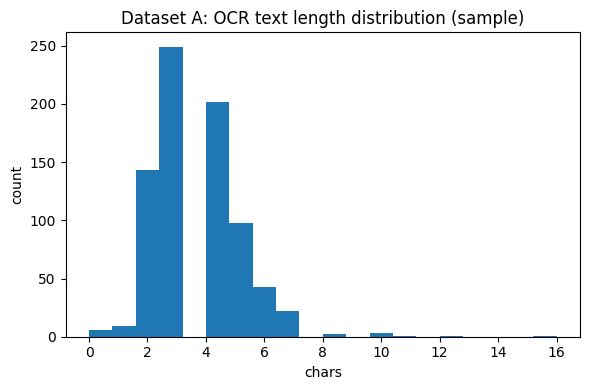

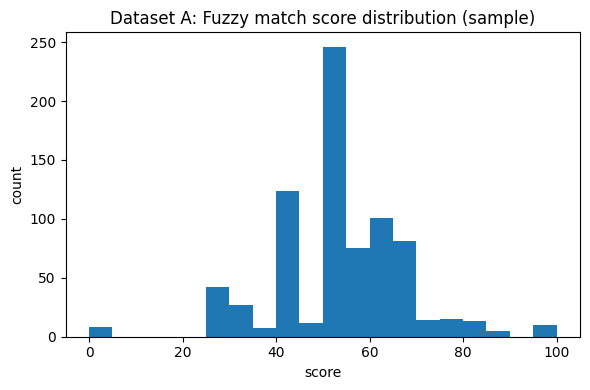

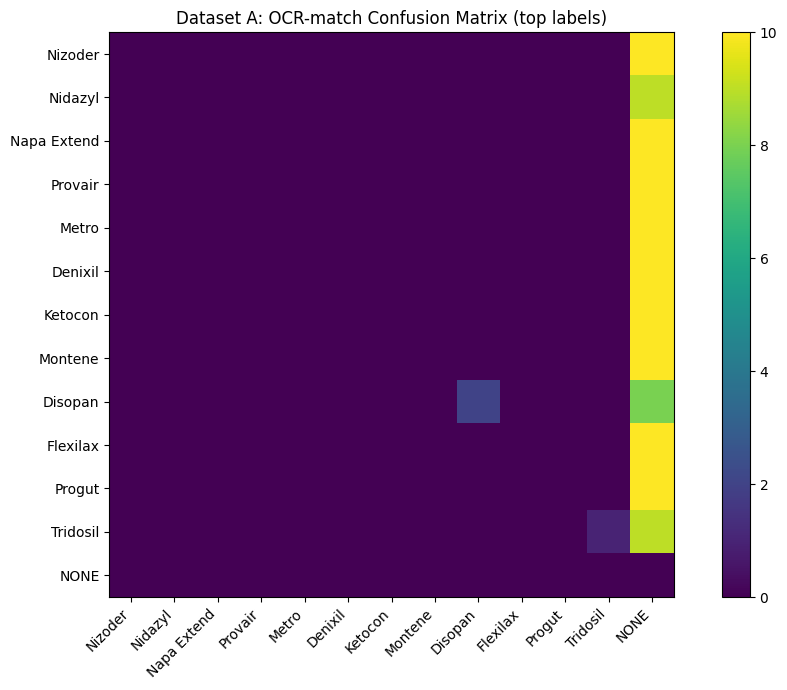

In [5]:
# ==========================================
# Block 5: Matching OCR text to Dataset A labels (comparison core)
# ==========================================

# Build vocabulary from mapping.json (medicine strings)
MED_VOCAB = list(mapping.keys())

def normalize_text(s):
    s = s.lower()
    s = re.sub(r"[^a-z0-9\s\-]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

MED_VOCAB_NORM = [normalize_text(x) for x in MED_VOCAB]

def best_medicine_match(ocr_text, score_cutoff=75):
    """
    Return best matched medicine string from mapping vocab using fuzzy match.
    """
    t = normalize_text(ocr_text)
    if not t:
        return None, 0
    match = process.extractOne(
        t, MED_VOCAB_NORM,
        scorer=fuzz.token_set_ratio
    )
    if match is None:
        return None, 0
    best_norm, score, idx = match[0], match[1], match[2]
    if score < score_cutoff:
        return None, score
    return MED_VOCAB[idx], score

def run_ocr_eval_on_dataset_A(df, img_dir, n_per_class=25, score_cutoff=75):
    """
    Evaluate OCR matching accuracy using Dataset A ground truth labels.
    Small subset for 10–20 min.
    """
    # subsample per class
    parts = []
    for cid in sorted(df["MEDICINE_NAME"].unique()):
        d = df[df["MEDICINE_NAME"] == cid]
        if len(d) > n_per_class:
            d = d.sample(n_per_class, random_state=SEED)
        parts.append(d)
    use_df = pd.concat(parts).sample(frac=1, random_state=SEED).reset_index(drop=True)

    y_true = []
    y_pred = []
    scores = []
    lens = []
    t0 = time.time()

    for _, row in use_df.iterrows():
        path = os.path.join(img_dir, row["IMAGE"])
        gt_id = int(row["MEDICINE_NAME"])
        gt_name = id_to_name[gt_id]

        img = cv2.imread(path)
        txt = ocr_with_rois(img, use_rois=False)  # A images are already cropped: full OCR is fine
        lens.append(len(txt))

        pred_name, sc = best_medicine_match(txt, score_cutoff=score_cutoff)
        scores.append(sc)

        y_true.append(gt_name)
        y_pred.append(pred_name if pred_name is not None else "__NONE__")

    elapsed = time.time() - t0
    acc = np.mean([t==p for t,p in zip(y_true, y_pred)])

    print(f"Dataset A OCR-match eval: N={len(use_df)} | acc={acc:.4f} | time={elapsed:.1f}s")
    return {
        "use_df": use_df,
        "y_true": y_true,
        "y_pred": y_pred,
        "scores": scores,
        "lens": lens,
        "acc": acc,
        "elapsed_sec": elapsed
    }

A_OCR_RESULT = run_ocr_eval_on_dataset_A(
    df=test_df, img_dir=TEST_IMG_DIR,
    n_per_class=25, score_cutoff=75
)

# Poster plots for Dataset A OCR quality
plt.figure(figsize=(6,4))
plt.hist(A_OCR_RESULT["lens"], bins=20)
plt.title("Dataset A: OCR text length distribution (sample)")
plt.xlabel("chars"); plt.ylabel("count")
plt.tight_layout(); plt.show()

plt.figure(figsize=(6,4))
plt.hist(A_OCR_RESULT["scores"], bins=20)
plt.title("Dataset A: Fuzzy match score distribution (sample)")
plt.xlabel("score"); plt.ylabel("count")
plt.tight_layout(); plt.show()

# Confusion matrix on top-K most frequent labels (for readable poster)
y_true = np.array(A_OCR_RESULT["y_true"])
y_pred = np.array(A_OCR_RESULT["y_pred"])

top_labels = pd.Series(y_true).value_counts().head(12).index.tolist()
mask = np.isin(y_true, top_labels)

cm = confusion_matrix(y_true[mask], y_pred[mask], labels=top_labels + ["__NONE__"])
plt.figure(figsize=(10,7))
plt.imshow(cm)
plt.title("Dataset A: OCR-match Confusion Matrix (top labels)")
plt.xticks(range(len(top_labels)+1), top_labels+["NONE"], rotation=45, ha="right")
plt.yticks(range(len(top_labels)+1), top_labels+["NONE"])
plt.colorbar()
plt.tight_layout()
plt.show()


Dataset B OCR processed: N=60 | hit_rate(any medicine in A vocab)=0.050 | time=71.3s


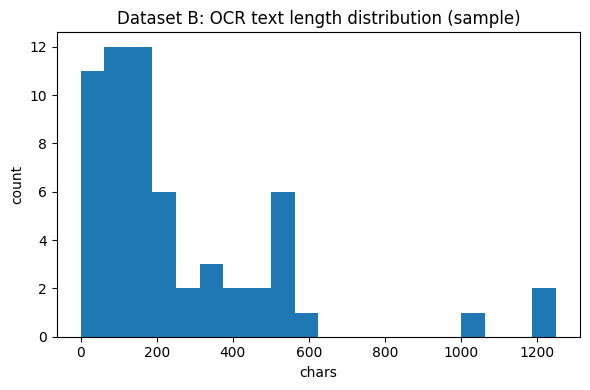

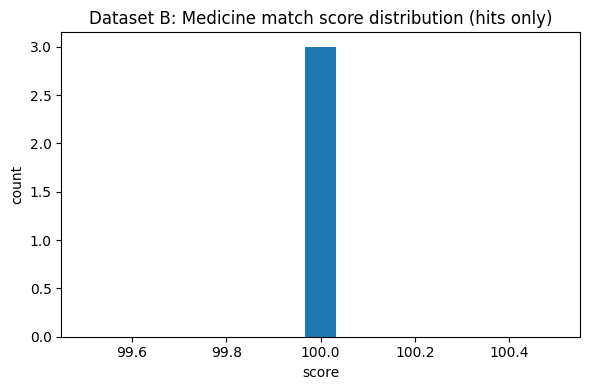

Saved: /kaggle/working/datasetB_demo_outputs.json
Saved ROI visualization: /kaggle/working/datasetB_roi_visualization.png
Saved ROI image: /kaggle/working/datasetB_roi_visualization.png

Sample JSON (first 2):
[
  {
    "file": "1.jpg",
    "ocr_preview": "Dr B. Who Farmstreet 12 Kirkville tel. 3876, R/ date | wav 1994 Diyorin ONT ny G&tteh de wot Sot dA 4 bMet b. ia Ms/Mr Patent 30 address; age: Ayo years",
    "entities": []
  },
  {
    "file": "10.jpg",
    "ocr_preview": "Sores Sapir with \u2018Mos Chiaty Rous obscene aoe axpnation proumeria ). ti usthr ceeds Deepal fer abot @ - Yo days $e Cormpluti. vecoveuy Thy Ht Lif ae hardly do-he needful .\nNe 500 086 nda + # ONO 258 10NE he + 9\" 40 ZIRCNONE B coterecmetyeupetnengtan com @ wwe watches or Bartarean | wuhreaove Se guliiten-h aae oe\nOx. menciibues DF Lm OF HOH SF ee ee...",
    "entities": []
  }
]


In [6]:
# ==========================================
# Block 6: Dataset B OCR + weak NER + comparison to A vocab
# ==========================================

# Weak NER patterns (fast, no training)
DOSAGE_RE = re.compile(r"\b\d+(\.\d+)?\s?(mg|ml|mcg|g|iu|units|tab|tablet|capsule|cap|drops|drop)\b", re.IGNORECASE)
FREQ_RE   = re.compile(r"\b(once|twice|thrice|daily|weekly|monthly|od|bd|tid|qid|q\d+h|every\s?\d+\s?hours|hs|stat)\b", re.IGNORECASE)

def weak_ner_from_text(text):
    t = text if text else ""
    entities = []

    # Medicine (use Dataset A mapping vocab as lexicon)
    best_med, score = best_medicine_match(t, score_cutoff=75)
    if best_med is not None:
        entities.append({"type": "DRUG", "text": best_med, "match_score": float(score)})

    # Dosage
    for m in DOSAGE_RE.finditer(t):
        entities.append({"type": "DOSAGE", "text": m.group(0)})

    # Frequency
    for m in FREQ_RE.finditer(t):
        entities.append({"type": "FREQUENCY", "text": m.group(0)})

    return entities

# Run on a small subset for 10–20 minutes
MAX_B = 60  # increase if you want
B_USE = B_IMAGES[:min(MAX_B, len(B_IMAGES))]

b_lens = []
b_hits = 0
b_scores = []
json_outputs = []

t0 = time.time()
for p in B_USE:
    img = cv2.imread(p)
    txt = ocr_with_rois(img, use_rois=True)

    b_lens.append(len(txt))
    med, sc = best_medicine_match(txt, score_cutoff=75)
    if med is not None:
        b_hits += 1
        b_scores.append(sc)

    ents = weak_ner_from_text(txt)

    json_outputs.append({
        "file": os.path.basename(p),
        "ocr_preview": (txt[:350] + "...") if len(txt) > 350 else txt,
        "entities": ents
    })

elapsed = time.time() - t0
hit_rate = b_hits / max(len(B_USE), 1)

print(f"Dataset B OCR processed: N={len(B_USE)} | hit_rate(any medicine in A vocab)={hit_rate:.3f} | time={elapsed:.1f}s")

# Poster plots for Dataset B
plt.figure(figsize=(6,4))
plt.hist(b_lens, bins=20)
plt.title("Dataset B: OCR text length distribution (sample)")
plt.xlabel("chars"); plt.ylabel("count")
plt.tight_layout(); plt.show()

if len(b_scores) > 0:
    plt.figure(figsize=(6,4))
    plt.hist(b_scores, bins=15)
    plt.title("Dataset B: Medicine match score distribution (hits only)")
    plt.xlabel("score"); plt.ylabel("count")
    plt.tight_layout(); plt.show()

# Save JSON outputs for report/poster
out_json = "/kaggle/working/datasetB_demo_outputs.json"
with open(out_json, "w", encoding="utf-8") as f:
    json.dump(json_outputs, f, indent=2)
print("Saved:", out_json)

# Save ROI visualization for poster (first image)
roi_img_out, _ = visualize_rois_save(B_USE[0], out_path="/kaggle/working/datasetB_roi_visualization.png")
print("Saved ROI image:", roi_img_out)

# Show first 2 JSON outputs in notebook
print("\nSample JSON (first 2):")
print(json.dumps(json_outputs[:2], indent=2))


In [7]:
# ==========================================
# Block 7: Comparison table for your poster
# ==========================================

summary = pd.DataFrame([
    {
        "dataset": "A (labeled crops)",
        "what_it_is": "cropped medicine images + label id",
        "metric": "OCR-match accuracy vs ground-truth label",
        "value": A_OCR_RESULT["acc"],
        "sample_size": len(A_OCR_RESULT["y_true"])
    },
    {
        "dataset": "B (full prescriptions)",
        "what_it_is": "full prescription images (no labels)",
        "metric": "OCR medicine hit-rate using A mapping vocab",
        "value": hit_rate,
        "sample_size": len(B_USE)
    }
])

print(summary)
out_csv = "/kaggle/working/A_vs_B_comparison.csv"
summary.to_csv(out_csv, index=False)
print("Saved:", out_csv)


                  dataset                            what_it_is  \
0       A (labeled crops)    cropped medicine images + label id   
1  B (full prescriptions)  full prescription images (no labels)   

                                        metric     value  sample_size  
0     OCR-match accuracy vs ground-truth label  0.030769          780  
1  OCR medicine hit-rate using A mapping vocab  0.050000           60  
Saved: /kaggle/working/A_vs_B_comparison.csv


**# For Model Selection From Annoted Dataset**

In [8]:
!pip -q install scikit-learn

import os, glob, json, zipfile, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights, densenet121, DenseNet121_Weights

from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.preprocessing import label_binarize

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [9]:
# ==========================================
# Block 2: Locate dataset root + load labels
# ==========================================

def find_processed_root():
    # Kaggle input search
    kaggle_input = "/kaggle/input"
    if os.path.exists(kaggle_input):
        for root, dirs, files in os.walk(kaggle_input):
            if "processed" in dirs:
                cand = os.path.join(root, "processed")
                if os.path.exists(os.path.join(cand, "train_labels.csv")):
                    return cand, "kaggle_input"

    # Zip fallback (ONLY if you uploaded zip to Kaggle working)
    # If you have a dataset zip in /kaggle/input, put path here
    zip_candidates = [
        "/kaggle/input/archive-1/archive (1).zip",  # example (may not exist)
        "/kaggle/working/archive (1).zip"
    ]
    for zpath in zip_candidates:
        if os.path.exists(zpath):
            extract_dir = "/kaggle/working/extracted_dataset"
            os.makedirs(extract_dir, exist_ok=True)
            with zipfile.ZipFile(zpath, "r") as zf:
                zf.extractall(extract_dir)
            # search extracted for processed
            for root, dirs, files in os.walk(extract_dir):
                if "processed" in dirs:
                    cand = os.path.join(root, "processed")
                    if os.path.exists(os.path.join(cand, "train_labels.csv")):
                        return cand, "zip_fallback"

    raise FileNotFoundError(
        "Could not locate data/processed with train_labels.csv. "
        "Make sure your dataset is added in Kaggle as an Input."
    )

PROC_ROOT, MODE = find_processed_root()
print("MODE:", MODE)
print("PROC_ROOT:", PROC_ROOT)

TRAIN_IMG_DIR = os.path.join(PROC_ROOT, "train", "images")
VAL_IMG_DIR   = os.path.join(PROC_ROOT, "val", "images")
TEST_IMG_DIR  = os.path.join(PROC_ROOT, "test", "images")

train_df = pd.read_csv(os.path.join(PROC_ROOT, "train_labels.csv"))
val_df   = pd.read_csv(os.path.join(PROC_ROOT, "val_labels.csv"))
test_df  = pd.read_csv(os.path.join(PROC_ROOT, "test_labels.csv"))

with open(os.path.join(PROC_ROOT, "mapping.json"), "r") as f:
    mapping = json.load(f)

# mapping is: medicine_name -> id
id_to_name = {v:k for k,v in mapping.items()}

NUM_CLASSES = len(mapping)
print("NUM_CLASSES:", NUM_CLASSES)
print("Train/Val/Test:", len(train_df), len(val_df), len(test_df))

# sanity check file exists
missing = 0
for fn in train_df["IMAGE"].head(10):
    if not os.path.exists(os.path.join(TRAIN_IMG_DIR, fn)):
        missing += 1
print("Missing (train first 10):", missing)


MODE: kaggle_input
PROC_ROOT: /kaggle/input/ocr-processed-handwritten-prescriptions/data/processed
NUM_CLASSES: 78
Train/Val/Test: 3120 780 780
Missing (train first 10): 0


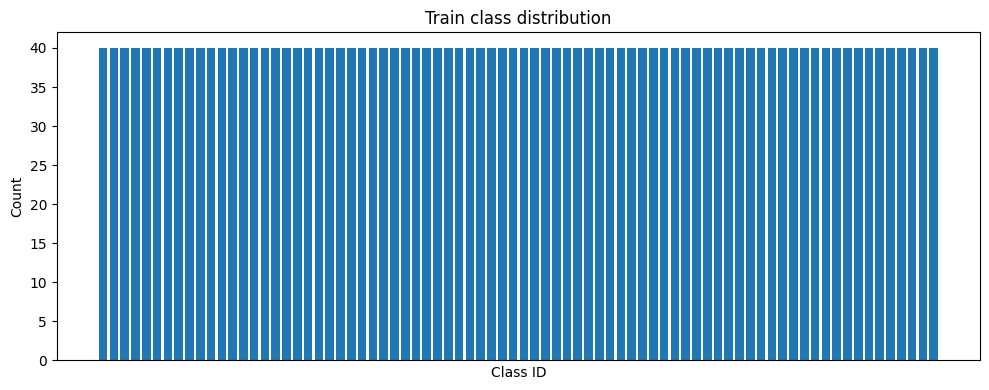

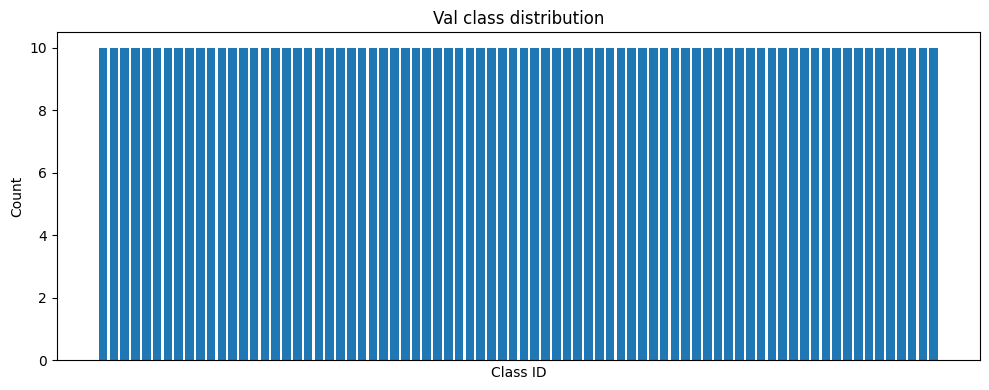

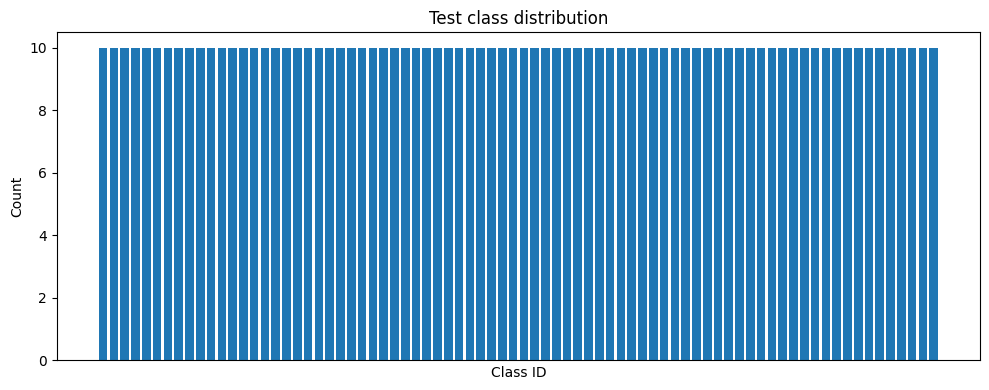

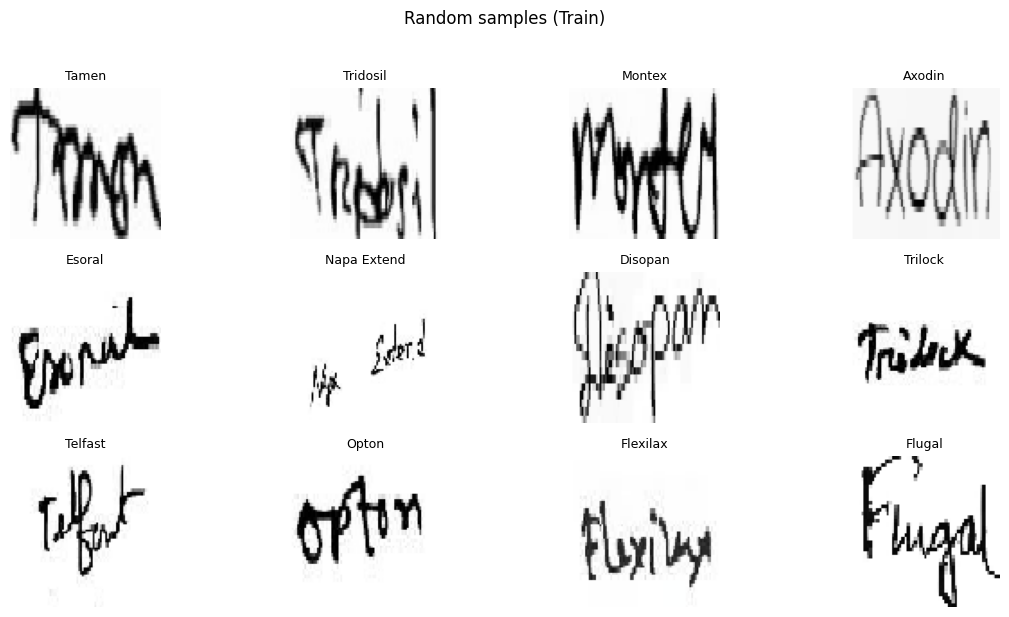

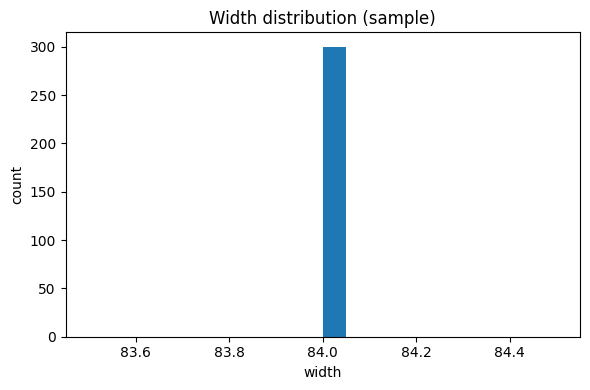

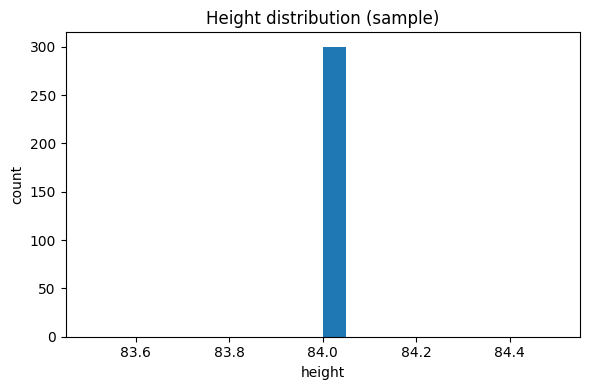

Unreadable images in sample: 0


In [10]:
# ==========================================
# Block 3: Dataset validation for poster
# ==========================================

def plot_class_dist(df, title):
    counts = df["MEDICINE_NAME"].value_counts().sort_index()
    plt.figure(figsize=(10,4))
    plt.bar(counts.index.astype(str), counts.values)
    plt.title(title)
    plt.xlabel("Class ID")
    plt.ylabel("Count")
    plt.xticks([], [])
    plt.tight_layout()
    plt.show()

plot_class_dist(train_df, "Train class distribution")
plot_class_dist(val_df, "Val class distribution")
plot_class_dist(test_df, "Test class distribution")

# Show a small grid of random training images with decoded label name
def show_samples(df, img_dir, n=12):
    samp = df.sample(min(n, len(df)), random_state=SEED).reset_index(drop=True)
    plt.figure(figsize=(12,6))
    for i in range(len(samp)):
        path = os.path.join(img_dir, samp.loc[i, "IMAGE"])
        y = int(samp.loc[i, "MEDICINE_NAME"])
        name = id_to_name.get(y, str(y))
        img = Image.open(path).convert("RGB")
        plt.subplot(3, 4, i+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(name[:16], fontsize=9)
    plt.suptitle("Random samples (Train)", y=1.02)
    plt.tight_layout()
    plt.show()

show_samples(train_df, TRAIN_IMG_DIR, n=12)

# Image size distribution (sample)
def plot_size_hist(df, img_dir, sample_n=300):
    samp = df.sample(min(sample_n, len(df)), random_state=SEED)
    ws, hs = [], []
    bad = 0
    for fn in samp["IMAGE"].values:
        p = os.path.join(img_dir, fn)
        try:
            img = Image.open(p)
            w,h = img.size
            ws.append(w); hs.append(h)
        except:
            bad += 1

    if len(ws) > 0:
        plt.figure(figsize=(6,4))
        plt.hist(ws, bins=20)
        plt.title("Width distribution (sample)")
        plt.xlabel("width"); plt.ylabel("count")
        plt.tight_layout(); plt.show()

        plt.figure(figsize=(6,4))
        plt.hist(hs, bins=20)
        plt.title("Height distribution (sample)")
        plt.xlabel("height"); plt.ylabel("count")
        plt.tight_layout(); plt.show()

    print("Unreadable images in sample:", bad)

plot_size_hist(train_df, TRAIN_IMG_DIR, sample_n=300)


In [11]:
# ==========================================
# Block 4: Dataset + loaders (fast subset)
# ==========================================

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(8),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.10, contrast=0.10),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
])

class MedImageDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        fn = self.df.loc[idx, "IMAGE"]
        y  = int(self.df.loc[idx, "MEDICINE_NAME"])
        path = os.path.join(self.img_dir, fn)
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, y

# ---- Fast subset so it finishes in 10–20 mins
SUBSAMPLE = True
MAX_PER_CLASS_TRAIN = 80     # adjust up if you want better results
MAX_PER_CLASS_VAL   = 40
MAX_PER_CLASS_TEST  = 40

def subsample_per_class(df, max_per_class):
    parts = []
    for c in sorted(df["MEDICINE_NAME"].unique()):
        d = df[df["MEDICINE_NAME"] == c]
        if len(d) > max_per_class:
            d = d.sample(max_per_class, random_state=SEED)
        parts.append(d)
    out = pd.concat(parts).sample(frac=1, random_state=SEED).reset_index(drop=True)
    return out

train_use = subsample_per_class(train_df, MAX_PER_CLASS_TRAIN) if SUBSAMPLE else train_df
val_use   = subsample_per_class(val_df,   MAX_PER_CLASS_VAL)   if SUBSAMPLE else val_df
test_use  = subsample_per_class(test_df,  MAX_PER_CLASS_TEST)  if SUBSAMPLE else test_df

print("Using sizes:", len(train_use), len(val_use), len(test_use))

train_ds = MedImageDataset(train_use, TRAIN_IMG_DIR, transform=train_tfms)
val_ds   = MedImageDataset(val_use,   VAL_IMG_DIR,   transform=eval_tfms)
test_ds  = MedImageDataset(test_use,  TEST_IMG_DIR,  transform=eval_tfms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)


Using sizes: 3120 780 780


In [12]:
# ==========================================
# Block 5: Train/Eval utilities + metrics
# ==========================================

def one_hot(y, num_classes):
    out = np.zeros((len(y), num_classes), dtype=np.float32)
    out[np.arange(len(y)), y] = 1.0
    return out

@torch.no_grad()
def predict_probs(model, loader):
    model.eval()
    probs_all, y_all = [], []
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        logits = model(xb)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        probs_all.append(probs)
        y_all.append(yb.numpy())
    return np.concatenate(probs_all), np.concatenate(y_all)

def compute_metrics(probs, y_true, num_classes):
    y_pred = probs.argmax(axis=1)
    f1 = f1_score(y_true, y_pred, average="macro")

    y_true_oh = one_hot(y_true, num_classes)
    try:
        auc = roc_auc_score(y_true_oh, probs, average="macro", multi_class="ovr")
    except Exception:
        auc = np.nan
    return f1, auc, y_pred

def plot_curves(hist, title):
    hist = pd.DataFrame(hist)
    plt.figure(figsize=(7,4))
    plt.plot(hist["epoch"], hist["train_loss"], label="train_loss")
    plt.plot(hist["epoch"], hist["val_loss"], label="val_loss")
    plt.title(title + " Loss"); plt.xlabel("epoch"); plt.ylabel("loss")
    plt.legend(); plt.tight_layout(); plt.show()

    plt.figure(figsize=(7,4))
    plt.plot(hist["epoch"], hist["train_auc"], label="train_auc")
    plt.plot(hist["epoch"], hist["val_auc"], label="val_auc")
    plt.title(title + " AUC (macro OVR)"); plt.xlabel("epoch"); plt.ylabel("auc")
    plt.legend(); plt.tight_layout(); plt.show()

    plt.figure(figsize=(7,4))
    plt.plot(hist["epoch"], hist["train_f1"], label="train_f1")
    plt.plot(hist["epoch"], hist["val_f1"], label="val_f1")
    plt.title(title + " F1 (macro)"); plt.xlabel("epoch"); plt.ylabel("f1")
    plt.legend(); plt.tight_layout(); plt.show()

def show_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    plt.imshow(cm)
    plt.title(title)
    plt.colorbar()
    plt.xlabel("Pred"); plt.ylabel("True")
    plt.tight_layout(); plt.show()

def train_one_model(
    name,
    model,
    epochs=3,
    lr=2e-4,
    weight_decay=1e-4,
    freeze_backbone=True,
    elasticnet=None  # {"l1":1e-7,"l2":1e-7} applied to trainable weights
):
    # freeze backbone (only if it makes sense)
    if freeze_backbone:
        for n, p in model.named_parameters():
            if ("fc" in n) or ("classifier" in n):
                p.requires_grad = True
            else:
                p.requires_grad = False

    trainable = [p for p in model.parameters() if p.requires_grad]
    print(f"{name}: trainable params =", sum(p.numel() for p in trainable))

    opt = torch.optim.AdamW(trainable, lr=lr, weight_decay=weight_decay)
    crit = nn.CrossEntropyLoss()

    best_val_auc = -1
    best_path = f"/kaggle/working/best_{name}.pt"
    hist = []

    scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

    for ep in range(1, epochs+1):
        t0 = time.time()
        model.train()
        total_loss = 0.0

        for xb, yb in train_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            opt.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                logits = model(xb)
                loss = crit(logits, yb)

                # ElasticNet penalty
                if elasticnet is not None:
                    l1 = elasticnet.get("l1", 0.0)
                    l2 = elasticnet.get("l2", 0.0)
                    if l1 > 0 or l2 > 0:
                        l1_term = 0.0
                        l2_term = 0.0
                        for p in trainable:
                            if p.ndim >= 2:
                                if l1 > 0: l1_term += p.abs().sum()
                                if l2 > 0: l2_term += (p*p).sum()
                        loss = loss + l1*l1_term + l2*l2_term

            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()

            total_loss += loss.item() * xb.size(0)

        train_loss = total_loss / len(train_loader.dataset)

        # train metrics
        tr_probs, tr_y = predict_probs(model, train_loader)
        tr_f1, tr_auc, _ = compute_metrics(tr_probs, tr_y, NUM_CLASSES)

        # val metrics + val loss
        model.eval()
        val_loss_sum = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device, non_blocking=True)
                yb = yb.to(device, non_blocking=True)
                logits = model(xb)
                loss = crit(logits, yb)
                val_loss_sum += loss.item() * xb.size(0)
        val_loss = val_loss_sum / len(val_loader.dataset)

        val_probs, val_y = predict_probs(model, val_loader)
        val_f1, val_auc, _ = compute_metrics(val_probs, val_y, NUM_CLASSES)

        hist.append({
            "epoch": ep,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_f1": tr_f1,
            "val_f1": val_f1,
            "train_auc": tr_auc,
            "val_auc": val_auc,
            "sec": time.time() - t0
        })

        gap_auc = (tr_auc - val_auc) if (not np.isnan(tr_auc) and not np.isnan(val_auc)) else np.nan
        print(f"[{name}] ep {ep}/{epochs} | loss {train_loss:.4f}/{val_loss:.4f} | "
              f"AUC {tr_auc:.4f}/{val_auc:.4f} | F1 {tr_f1:.4f}/{val_f1:.4f} | "
              f"gap_auc={gap_auc:.4f} | {hist[-1]['sec']:.1f}s")

        if not np.isnan(val_auc) and val_auc > best_val_auc:
            best_val_auc = val_auc
            torch.save({"state_dict": model.state_dict(), "num_classes": NUM_CLASSES}, best_path)
            print("  ✅ saved best:", best_path)

    # save history csv
    hist_df = pd.DataFrame(hist)
    hist_csv = f"/kaggle/working/history_{name}.csv"
    hist_df.to_csv(hist_csv, index=False)
    print("Saved history:", hist_csv)

    # load best & test
    ckpt = torch.load(best_path, map_location=device)
    model.load_state_dict(ckpt["state_dict"])

    test_probs, test_y = predict_probs(model, test_loader)
    test_f1, test_auc, test_pred = compute_metrics(test_probs, test_y, NUM_CLASSES)

    print("\n===== TEST:", name, "=====")
    print("Test AUC (macro OVR):", test_auc)
    print("Test F1 (macro):     ", test_f1)
    print(classification_report(test_y, test_pred))

    plot_curves(hist, title=name)
    show_cm(test_y, test_pred, title=f"{name} Confusion Matrix (test)")

    return {
        "model": name,
        "best_path": best_path,
        "history_csv": hist_csv,
        "best_val_auc": best_val_auc,
        "test_auc": test_auc,
        "test_f1": test_f1
    }


In [13]:
# ==========================================
# Block 6: Define 3 models
# ==========================================

class SmallCNN(nn.Module):
    def __init__(self, num_classes, dropout=0.35):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.net(x)

# NOTE: pretrained weights require internet.
# If internet is OFF, it will auto use random init (weights=None).
def build_resnet50(num_classes, pretrained=True):
    weights = ResNet50_Weights.DEFAULT if pretrained else None
    m = resnet50(weights=weights)
    in_features = m.fc.in_features
    m.fc = nn.Sequential(nn.Dropout(0.3), nn.Linear(in_features, num_classes))
    return m

def build_densenet121(num_classes, pretrained=True):
    weights = DenseNet121_Weights.DEFAULT if pretrained else None
    m = densenet121(weights=weights)
    in_features = m.classifier.in_features
    m.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(in_features, num_classes))
    return m

# Try pretrained, fallback to random init if it fails
def safe_model(builder_fn, name):
    try:
        m = builder_fn(NUM_CLASSES, pretrained=True)
        print(f"✅ {name}: pretrained loaded")
        return m
    except Exception as e:
        print(f"⚠️ {name}: pretrained failed -> random init. Reason:", str(e)[:200], "...")
        m = builder_fn(NUM_CLASSES, pretrained=False)
        return m

resnet_model = safe_model(build_resnet50, "ResNet50").to(device)
dense_model  = safe_model(build_densenet121, "DenseNet121").to(device)

elasticnet_model = SmallCNN(NUM_CLASSES, dropout=0.35).to(device)  # baseline CNN
print("✅ All models created.")


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 168MB/s]


✅ ResNet50: pretrained loaded
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 155MB/s]

✅ DenseNet121: pretrained loaded
✅ All models created.


resnet50: trainable params = 159822


/tmp/ipykernel_24/3138636528.py:89: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
/tmp/ipykernel_24/3138636528.py:102: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


[resnet50] ep 1/3 | loss 4.3306/4.2537 | AUC 0.7464/0.7280 | F1 0.0826/0.0608 | gap_auc=0.0184 | 39.0s
  ✅ saved best: /kaggle/working/best_resnet50.pt


/tmp/ipykernel_24/3138636528.py:102: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


[resnet50] ep 2/3 | loss 4.2002/4.1448 | AUC 0.8214/0.8144 | F1 0.1462/0.1027 | gap_auc=0.0070 | 25.8s
  ✅ saved best: /kaggle/working/best_resnet50.pt


/tmp/ipykernel_24/3138636528.py:102: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


[resnet50] ep 3/3 | loss 4.1020/4.0685 | AUC 0.8445/0.8329 | F1 0.1649/0.1149 | gap_auc=0.0116 | 26.2s
  ✅ saved best: /kaggle/working/best_resnet50.pt
Saved history: /kaggle/working/history_resnet50.csv

===== TEST: resnet50 =====
Test AUC (macro OVR): 0.7214535464535464
Test F1 (macro):      0.05890394620528319
              precision    recall  f1-score   support

           0       0.09      0.10      0.10        10
           1       0.33      0.10      0.15        10
           2       0.00      0.00      0.00        10
           3       0.00      0.00      0.00        10
           4       0.00      0.00      0.00        10
           5       0.00      0.00      0.00        10
           6       0.06      0.20      0.09        10
           7       1.00      0.20      0.33        10
           8       0.50      0.50      0.50        10
           9       1.00      0.10      0.18        10
          10       0.25      0.30      0.27        10
          11       0.05      0.60   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


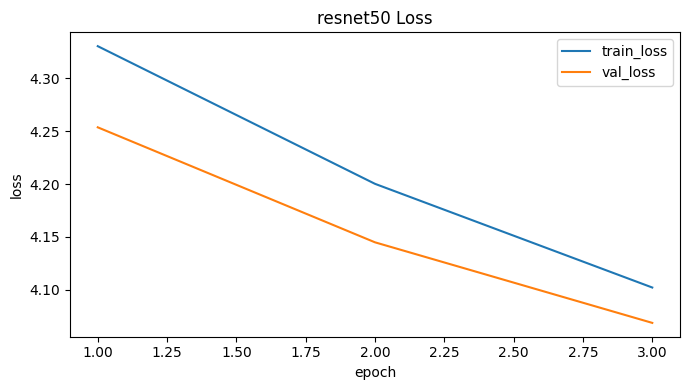

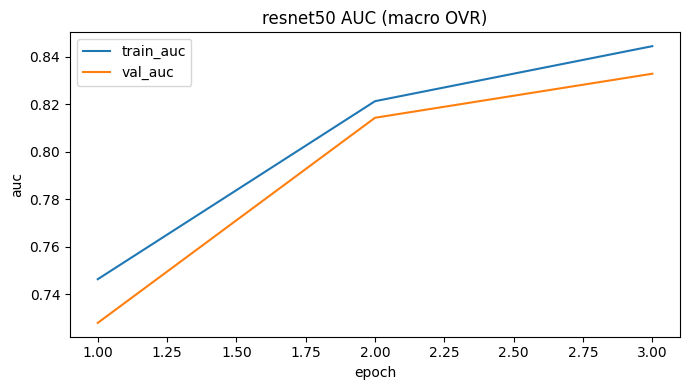

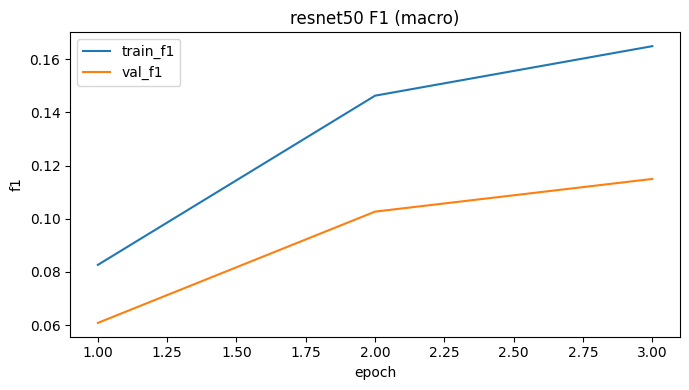

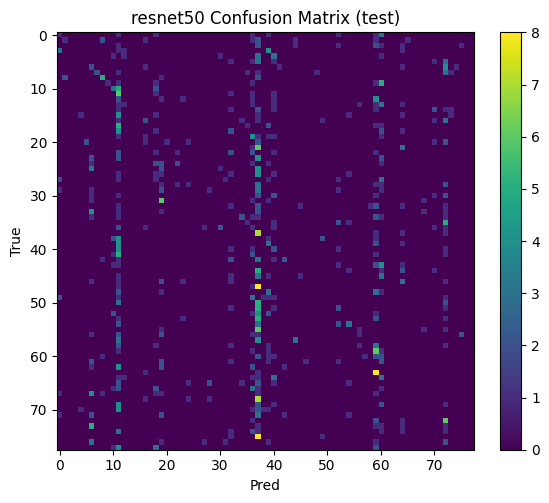

densenet121: trainable params = 79950


/tmp/ipykernel_24/3138636528.py:89: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
/tmp/ipykernel_24/3138636528.py:102: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


[densenet121] ep 1/3 | loss 4.4470/4.2818 | AUC 0.6142/0.6264 | F1 0.0241/0.0184 | gap_auc=-0.0122 | 26.8s
  ✅ saved best: /kaggle/working/best_densenet121.pt


/tmp/ipykernel_24/3138636528.py:102: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


[densenet121] ep 2/3 | loss 4.2938/4.1509 | AUC 0.7119/0.7163 | F1 0.0620/0.0619 | gap_auc=-0.0044 | 27.9s
  ✅ saved best: /kaggle/working/best_densenet121.pt


/tmp/ipykernel_24/3138636528.py:102: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


[densenet121] ep 3/3 | loss 4.1797/4.0372 | AUC 0.7738/0.7688 | F1 0.0981/0.0847 | gap_auc=0.0050 | 27.8s
  ✅ saved best: /kaggle/working/best_densenet121.pt
Saved history: /kaggle/working/history_densenet121.csv

===== TEST: densenet121 =====
Test AUC (macro OVR): 0.6526023976023975
Test F1 (macro):      0.031248177090721585
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        10
           1       0.00      0.00      0.00        10
           2       0.00      0.00      0.00        10
           3       0.20      0.10      0.13        10
           4       0.12      0.10      0.11        10
           5       0.00      0.00      0.00        10
           6       0.00      0.00      0.00        10
           7       0.00      0.00      0.00        10
           8       0.15      0.30      0.20        10
           9       0.12      0.50      0.19        10
          10       0.00      0.00      0.00        10
          11       0.09

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


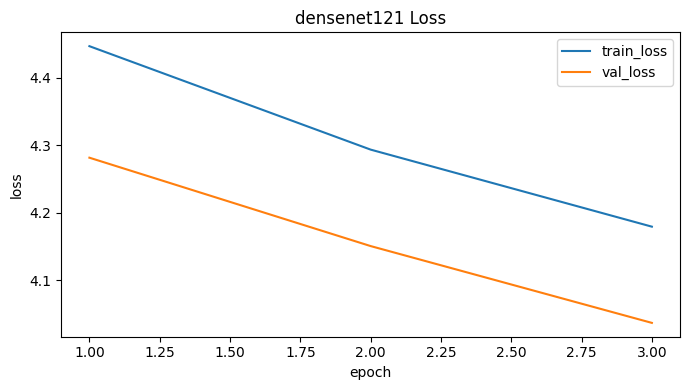

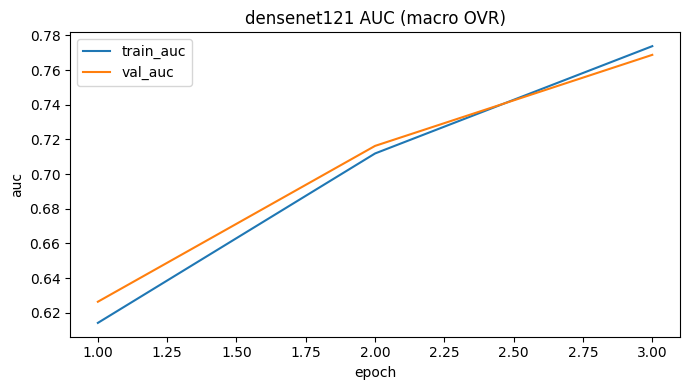

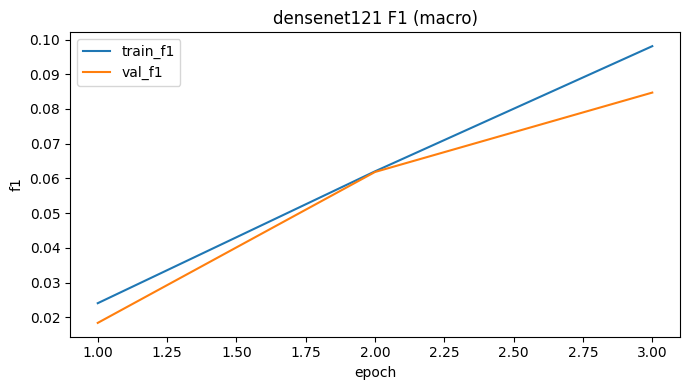

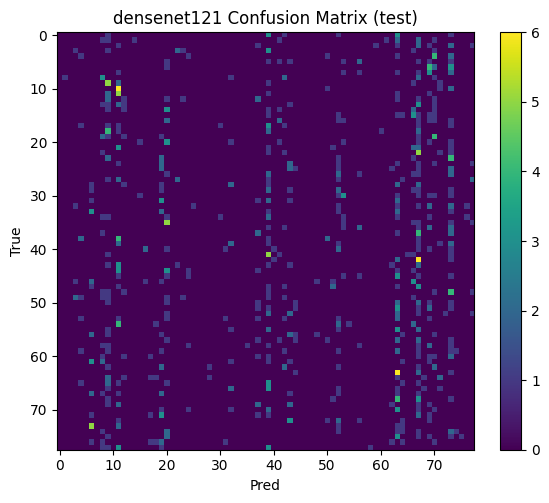

elasticnet_cnn: trainable params = 408462


/tmp/ipykernel_24/3138636528.py:89: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
/tmp/ipykernel_24/3138636528.py:102: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


[elasticnet_cnn] ep 1/3 | loss 4.3434/4.2206 | AUC 0.6152/0.6565 | F1 0.0025/0.0047 | gap_auc=-0.0413 | 23.2s
  ✅ saved best: /kaggle/working/best_elasticnet_cnn.pt


/tmp/ipykernel_24/3138636528.py:102: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


[elasticnet_cnn] ep 2/3 | loss 4.2695/4.1634 | AUC 0.6419/0.6868 | F1 0.0020/0.0023 | gap_auc=-0.0449 | 23.4s
  ✅ saved best: /kaggle/working/best_elasticnet_cnn.pt


/tmp/ipykernel_24/3138636528.py:102: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


[elasticnet_cnn] ep 3/3 | loss 4.2144/4.0777 | AUC 0.6628/0.7047 | F1 0.0073/0.0071 | gap_auc=-0.0419 | 23.1s
  ✅ saved best: /kaggle/working/best_elasticnet_cnn.pt
Saved history: /kaggle/working/history_elasticnet_cnn.csv

===== TEST: elasticnet_cnn =====
Test AUC (macro OVR): 0.5591575091575092
Test F1 (macro):      0.0028090474471483226
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        10
           1       0.00      0.00      0.00        10
           2       0.00      0.00      0.00        10
           3       0.00      0.00      0.00        10
           4       0.00      0.00      0.00        10
           5       0.00      0.00      0.00        10
           6       0.00      0.00      0.00        10
           7       0.00      0.00      0.00        10
           8       0.00      0.00      0.00        10
           9       0.00      0.00      0.00        10
          10       0.00      0.00      0.00        10
         

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


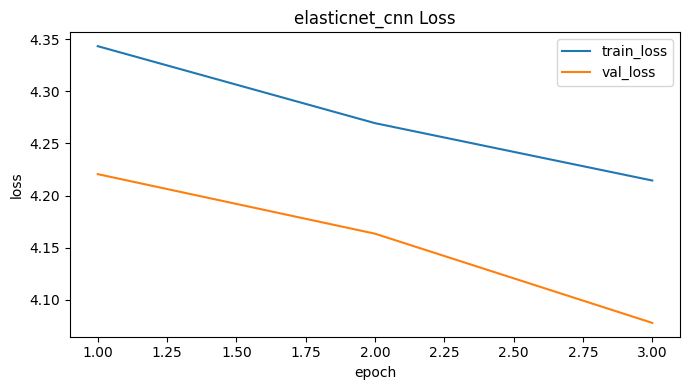

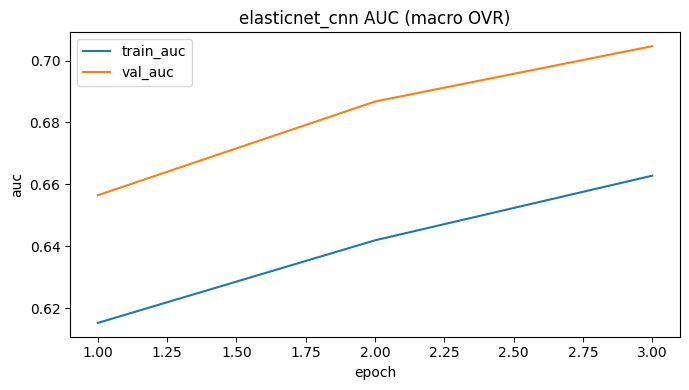

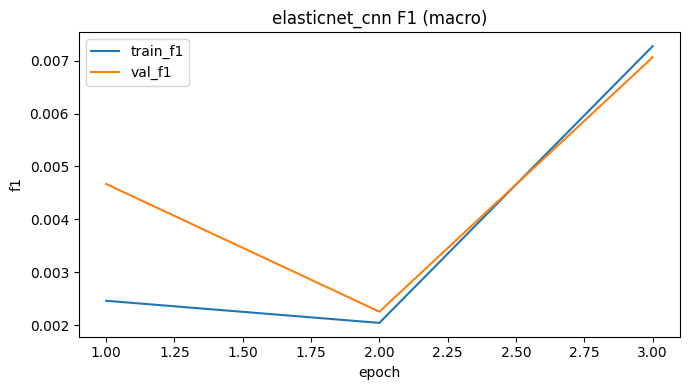

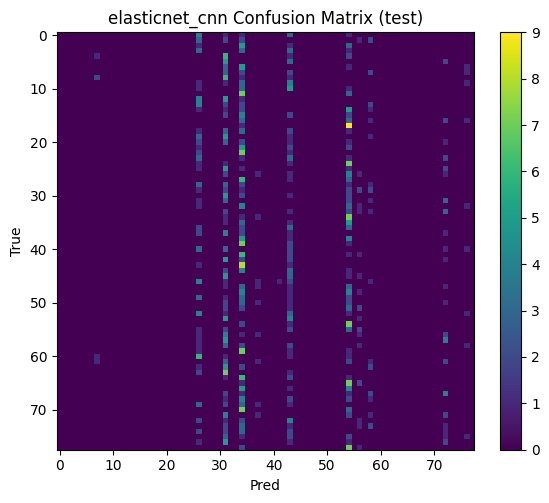


=== MODEL COMPARISON ===


,model,best_path,history_csv,best_val_auc,test_auc,test_f1
0,resnet50,/kaggle/working/best_resnet50.pt,/kaggle/working/history_resnet50.csv,0.832947,0.721454,0.058904
1,densenet121,/kaggle/working/best_densenet121.pt,/kaggle/working/history_densenet121.csv,0.768751,0.652602,0.031248
2,elasticnet_cnn,/kaggle/working/best_elasticnet_cnn.pt,/kaggle/working/history_elasticnet_cnn.csv,0.704669,0.559158,0.002809


Saved: /kaggle/working/model_comparison.csv

Saved best models:
 - /kaggle/working/best_resnet50.pt
 - /kaggle/working/best_densenet121.pt
 - /kaggle/working/best_elasticnet_cnn.pt


In [14]:
# ==========================================
# Block 7: Train all 3 and compare
# ==========================================

EPOCHS = 3  # fast
results = []

# ResNet50 (freeze backbone if pretrained worked; if random init, you can set freeze_backbone=False)
results.append(train_one_model(
    name="resnet50",
    model=resnet_model,
    epochs=EPOCHS,
    lr=2e-4,
    weight_decay=1e-4,
    freeze_backbone=True,
    elasticnet=None
))

# DenseNet121
results.append(train_one_model(
    name="densenet121",
    model=dense_model,
    epochs=EPOCHS,
    lr=2e-4,
    weight_decay=1e-4,
    freeze_backbone=True,
    elasticnet=None
))

# ElasticNet-regularized SmallCNN (no freezing)
results.append(train_one_model(
    name="elasticnet_cnn",
    model=elasticnet_model,
    epochs=EPOCHS,
    lr=5e-4,
    weight_decay=0.0,
    freeze_backbone=False,
    elasticnet={"l1": 1e-7, "l2": 1e-7}
))

summary = pd.DataFrame(results).sort_values("test_auc", ascending=False)
print("\n=== MODEL COMPARISON ===")
display(summary)

out_csv = "/kaggle/working/model_comparison.csv"
summary.to_csv(out_csv, index=False)
print("Saved:", out_csv)

print("\nSaved best models:")
for r in results:
    print(" -", r["best_path"])
